In [7]:
import os
import joblib


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [8]:
data_directory = 'G:/My Drive/kaggle_data/FoG_prediction/'

In [9]:
def fill_missing_values(df):
    """
    Replaces missing values with the median value for each numerical column.

    :param df: pandas DataFrame, the dataset in which missing values need to be replaced
    :return: pandas DataFrame, the dataset with replaced missing values
    """
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns  # Selecting all numerical columns
    for col in numeric_cols:
        median = df[col].median()  # Finding the Median Value of a Column
        df[col].fillna(median, inplace=True)   # Replacing Missing Values with the Median Value
    return df

In [10]:
def explore_dataframe(df):
    print("Shape of dataframe:", df.shape)
    
    display(df.head())
    
    print("Info of dataframe:\n")
    df.info()
         
    print("Missing values in dataframe:\n", df.isnull().sum())
    
    print("Duplicate rows in dataframe:", df.duplicated().sum())

In [11]:
def check_missing_values(df):
    """
    Checks the count of missing values in each column of a DataFrame.

    :param df: pandas.DataFrame, the DataFrame to check for missing values.
    :return: pandas.DataFrame, the DataFrame with information about missing values.
    """
    return df.isnull().sum()

### Metadata

In [12]:
tdcsfog_metadata_df = pd.read_csv(data_directory+"tdcsfog_metadata.csv")
defog_metadata_df = pd.read_csv(data_directory+"defog_metadata.csv")
subjects_df = pd.read_csv(data_directory+"subjects.csv")
events_df = pd.read_csv(data_directory+"events.csv")
tasks_df = pd.read_csv(data_directory+"tasks.csv")
daily_metadata_df = pd.read_csv(data_directory+"daily_metadata.csv")

In [13]:
explore_dataframe(tdcsfog_metadata_df)

Shape of dataframe: (833, 5)


,Id,Subject,Visit,Test,Medication
0,003f117e14,4dc2f8,3,2,on
1,009ee11563,f62eec,4,2,on
2,011322847a,231c3b,2,2,on
3,01d0fe7266,231c3b,2,1,off
4,024418ba39,fa8764,19,3,on


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Id          833 non-null    object
 1   Subject     833 non-null    object
 2   Visit       833 non-null    int64 
 3   Test        833 non-null    int64 
 4   Medication  833 non-null    object
dtypes: int64(2), object(3)
memory usage: 32.7+ KB
Missing values in dataframe:
 Id            0
Subject       0
Visit         0
Test          0
Medication    0
dtype: int64
Duplicate rows in dataframe: 0


In [14]:
explore_dataframe(defog_metadata_df)

Shape of dataframe: (137, 4)


,Id,Subject,Visit,Medication
0,02ab235146,e1f62e,2,on
1,02ea782681,ae2d35,2,on
2,06414383cf,8c1f5e,2,off
3,092b4c1819,2874c5,1,off
4,0a900ed8a2,0e3d49,2,on


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Id          137 non-null    object
 1   Subject     137 non-null    object
 2   Visit       137 non-null    int64 
 3   Medication  137 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.4+ KB
Missing values in dataframe:
 Id            0
Subject       0
Visit         0
Medication    0
dtype: int64
Duplicate rows in dataframe: 0


In [15]:
explore_dataframe(subjects_df)

Shape of dataframe: (173, 8)


,Subject,Visit,Age,Sex,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ
0,00f674,2.0,63,M,27.0,43.0,49.0,24
1,00f674,1.0,63,M,27.0,31.0,30.0,26
2,02bc69,NaN,69,M,4.0,21.0,NaN,22
3,040587,2.0,75,M,26.0,52.0,69.0,21
4,040587,1.0,75,M,26.0,47.0,75.0,24


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subject       173 non-null    object 
 1   Visit         111 non-null    float64
 2   Age           173 non-null    int64  
 3   Sex           173 non-null    object 
 4   YearsSinceDx  173 non-null    float64
 5   UPDRSIII_On   172 non-null    float64
 6   UPDRSIII_Off  132 non-null    float64
 7   NFOGQ         173 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 10.9+ KB
Missing values in dataframe:
 Subject          0
Visit           62
Age              0
Sex              0
YearsSinceDx     0
UPDRSIII_On      1
UPDRSIII_Off    41
NFOGQ            0
dtype: int64
Duplicate rows in dataframe: 0


In [16]:
explore_dataframe(events_df)

Shape of dataframe: (3544, 5)


,Id,Init,Completion,Type,Kinetic
0,003f117e14,8.61312,14.7731,Turn,1.0
1,009ee11563,11.38470,41.1847,Turn,1.0
2,009ee11563,54.66470,58.7847,Turn,1.0
3,011322847a,28.09660,30.2966,Turn,1.0
4,01d0fe7266,30.31840,31.8784,Turn,1.0


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          3544 non-null   object 
 1   Init        3544 non-null   float64
 2   Completion  3544 non-null   float64
 3   Type        2502 non-null   object 
 4   Kinetic     2502 non-null   float64
dtypes: float64(3), object(2)
memory usage: 138.6+ KB
Missing values in dataframe:
 Id               0
Init             0
Completion       0
Type          1042
Kinetic       1042
dtype: int64
Duplicate rows in dataframe: 0


In [17]:
explore_dataframe(tasks_df)

Shape of dataframe: (2817, 4)


,Id,Begin,End,Task
0,02ab235146,10.00,190.48,Rest1
1,02ab235146,211.24,271.56,Rest2
2,02ab235146,505.88,522.40,4MW
3,02ab235146,577.96,594.64,4MW-C
4,02ab235146,701.32,715.28,MB1


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2817 entries, 0 to 2816
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      2817 non-null   object 
 1   Begin   2817 non-null   float64
 2   End     2817 non-null   float64
 3   Task    2817 non-null   object 
dtypes: float64(2), object(2)
memory usage: 88.2+ KB
Missing values in dataframe:
 Id       0
Begin    0
End      0
Task     0
dtype: int64
Duplicate rows in dataframe: 0


In [18]:
# List of all datasets

datasets = [tdcsfog_metadata_df, defog_metadata_df, events_df, tasks_df, subjects_df]

# Dataset merging

merged_data = pd.concat(datasets, axis=1, join='outer')

# Removing duplicate columns

merged_data = merged_data.loc[:, ~merged_data.columns.duplicated()]

# Merging rows with the same column names

merged_data['Subject'] = merged_data['Subject'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

# Removing 'Id' and 'Subject' columns

merged_data = merged_data.drop(['Id', 'Subject'], axis=1)

In [19]:
# Replacing values in the 'Sex' column

merged_data['Sex'] = merged_data['Sex'].replace({'M': 1, 'F': 0})

# Replacing values in the 'Medication' column

merged_data['Medication'] = merged_data['Medication'].replace({'on': 1, 'off': 0})

C:\Users\35262\AppData\Local\Temp\ipykernel_5884\3045597151.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_data['Sex'] = merged_data['Sex'].replace({'M': 1, 'F': 0})
C:\Users\35262\AppData\Local\Temp\ipykernel_5884\3045597151.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_data['Medication'] = merged_data['Medication'].replace({'on': 1, 'off': 0})


In [20]:
merged_data['Visit'] = merged_data['Visit'].fillna(0).astype(int)
merged_data['Test'] = merged_data['Test'].fillna(0).astype(int)
merged_data['Kinetic'] = merged_data['Kinetic'].fillna(0).astype(int)
merged_data['Age'] = merged_data['Age'].fillna(0).astype(int)
merged_data['YearsSinceDx'] = merged_data['YearsSinceDx'].fillna(0).astype(int)
merged_data['UPDRSIII_On'] = merged_data['UPDRSIII_On'].fillna(0).astype(int)
merged_data['UPDRSIII_Off'] = merged_data['UPDRSIII_Off'].fillna(0).astype(int)
merged_data['NFOGQ'] = merged_data['NFOGQ'].fillna(0).astype(int)
merged_data['Sex'] = merged_data['Sex'].fillna(0).astype(int)
merged_data['Medication'] = merged_data['Medication'].fillna(0).astype(int)

In [21]:
# Mode imputation

columns_mode = ['Sex', 'Medication', 'Age', 'YearsSinceDx', 'UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']
merged_data[columns_mode] = merged_data[columns_mode].fillna(merged_data[columns_mode].mode().iloc[0])

# Median imputation

columns_median = ['Begin', 'End', 'Init', 'Completion', 'Kinetic', 'Visit', 'Test']
merged_data[columns_median] = merged_data[columns_median].fillna(merged_data[columns_median].median())

# Dropping rows with missing values in columns 'Type' and 'Task'

merged_data = merged_data.dropna(subset=['Type', 'Task'])

In [22]:
# Outputting the final dataset

explore_dataframe(merged_data.head(5))

Shape of dataframe: (5, 16)


,Visit,Test,Medication,Init,Completion,Type,Kinetic,Begin,End,Task,Age,Sex,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ
0,3,2,1,8.61312,14.7731,Turn,1,10.00,190.48,Rest1,63,1,27,43,49,24
1,4,2,1,11.38470,41.1847,Turn,1,211.24,271.56,Rest2,63,1,27,31,30,26
2,2,2,1,54.66470,58.7847,Turn,1,505.88,522.40,4MW,69,1,4,21,0,22
3,2,1,0,28.09660,30.2966,Turn,1,577.96,594.64,4MW-C,75,1,26,52,69,21
4,19,3,1,30.31840,31.8784,Turn,1,701.32,715.28,MB1,75,1,26,47,75,24


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 4
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Visit         5 non-null      int32  
 1   Test          5 non-null      int32  
 2   Medication    5 non-null      int32  
 3   Init          5 non-null      float64
 4   Completion    5 non-null      float64
 5   Type          5 non-null      object 
 6   Kinetic       5 non-null      int32  
 7   Begin         5 non-null      float64
 8   End           5 non-null      float64
 9   Task          5 non-null      object 
 10  Age           5 non-null      int32  
 11  Sex           5 non-null      int32  
 12  YearsSinceDx  5 non-null      int32  
 13  UPDRSIII_On   5 non-null      int32  
 14  UPDRSIII_Off  5 non-null      int32  
 15  NFOGQ         5 non-null      int32  
dtypes: float64(4), int32(10), object(2)
memory usage: 480.0+ bytes
Missing values in dataframe:
 Visit       

In [23]:
merged_data[['UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']].describe()

,UPDRSIII_On,UPDRSIII_Off,NFOGQ
count,1992.000000,1992.000000,1992.000000
mean,2.959337,2.841365,1.486948
std,10.326603,11.177439,5.311949
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,79.000000,91.000000,29.000000


In [24]:
# Remove NaN values
on_scores = subjects_df['UPDRSIII_On'].dropna()
off_scores = subjects_df['UPDRSIII_Off'].dropna()

# Perform KDE using scipy's gaussian_kde
kde_on = gaussian_kde(on_scores)
kde_off = gaussian_kde(off_scores)

# Create a range for UPDRS scores
x_range = np.linspace(0, max(on_scores.max(), off_scores.max()), 100)

# Calculate KDE for the range
kde_values_on = kde_on(x_range)
kde_values_off = kde_off(x_range)

fig = go.Figure()

# Add KDE for UPDRSIII_On
fig.add_trace(go.Scatter(
    x=x_range, y=kde_values_on, 
    mode='lines', 
    name='On', 
    line=dict(color='purple', width=3),
    fill='tozeroy', opacity=0.4
))

# Add KDE for UPDRSIII_Off
fig.add_trace(go.Scatter(
    x=x_range, y=kde_values_off, 
    mode='lines', 
    name='Off', 
    line=dict(color='orange', width=3),
    fill='tozeroy', opacity=0.4
))

fig.update_layout(
    xaxis_title='UPDRS Score',
    yaxis_title='Density',
    xaxis=dict(titlefont=dict(color='black')),
    yaxis=dict(titlefont=dict(color='black')),
    legend_title="Medication Status"
)

fig.show()

In [25]:
melted_df = subjects_df.melt(value_vars=['UPDRSIII_On', 'UPDRSIII_Off'],
                              var_name='Medication_Status',
                              value_name='UPDRS_Score')

# Create the horizontal boxplot
fig = px.box(melted_df, 
              y='Medication_Status',  
              x='UPDRS_Score', 
              title='UPDRS Scores by Medication Status',
              labels={'Medication_Status': '', 'UPDRS_Score': 'UPDRS Score'},
              color='Medication_Status', 
              color_discrete_sequence=["purple", "orange"]  
             )


fig.show()

In [26]:
# Melt the DataFrame to long format to include both UPDRS On and Off scores
melted_df = subjects_df.melt(id_vars=['Subject', 'Sex'], 
                             value_vars=['UPDRSIII_On', 'UPDRSIII_Off'],
                             var_name='Medication_Status', 
                             value_name='UPDRS_Score')

# Remove rows with missing UPDRS scores
melted_df_clean = melted_df.dropna(subset=['UPDRS_Score', 'Sex'])

# Create a boxplot comparing UPDRS On and Off scores by Sex
fig = px.box(melted_df_clean, 
             y='Medication_Status', 
             x='UPDRS_Score', 
             color='Sex',
             title='UPDRS On and Off Scores by Sex',
             labels={'UPDRS_Score': 'UPDRS Score', 'Medication_Status': ''},
             color_discrete_sequence=["blue", "red"]  
            )


fig.show()

### Unsurprisingly, those off medications have higher UPDRS scores. 
### The distribution of UPDRS scores for men is centered around higher scores than for women.

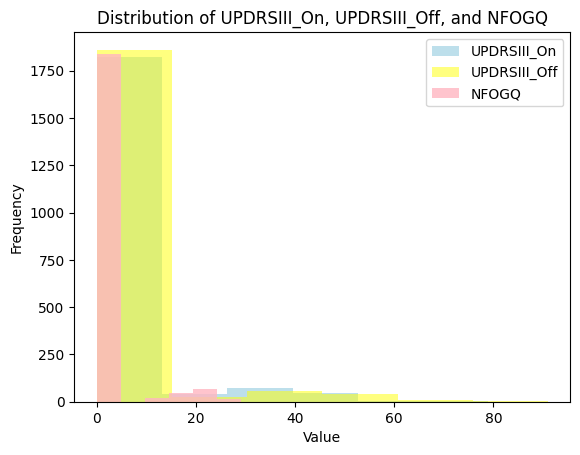

In [27]:
# Create a figure and axes for the plot

fig, ax = plt.subplots()

# Plot the histogram for the 'UPDRSIII_On' column and set the color

ax.hist(merged_data['UPDRSIII_On'], bins=6, color='lightblue', alpha=0.8, label='UPDRSIII_On')

# Plot the histogram for the 'UPDRSIII_Off' column and set the color

ax.hist(merged_data['UPDRSIII_Off'], bins=6, color='yellow', alpha=0.5, label='UPDRSIII_Off')

# Plot the histogram for the 'NFOGQ' column and set the color

ax.hist(merged_data['NFOGQ'], bins=6, color='lightpink', alpha=0.8, label='NFOGQ')

# Set the labels for the x and y axes, and the title
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of UPDRSIII_On, UPDRSIII_Off, and NFOGQ')

# Add a legend
ax.legend()

# Display the plot
plt.show()

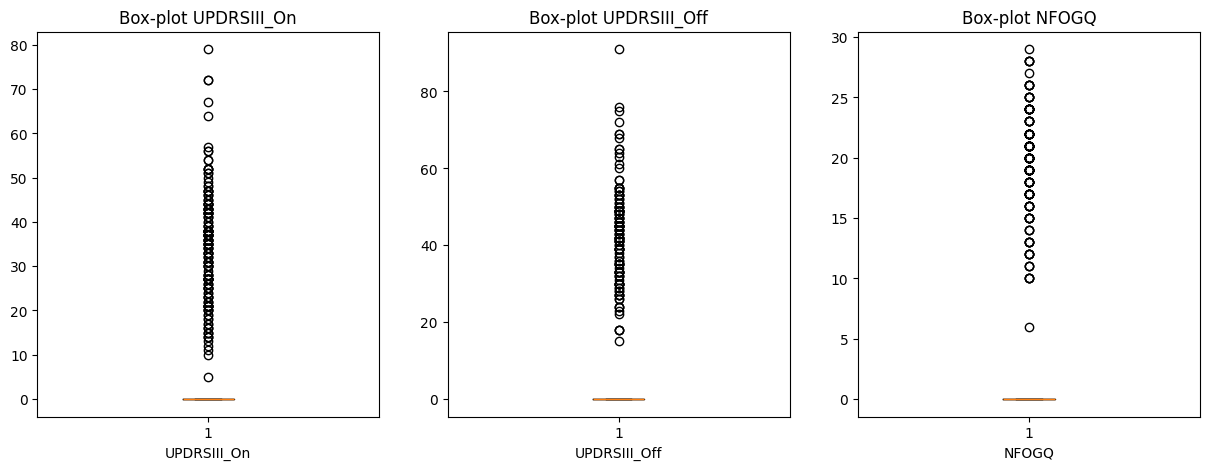

In [28]:
# Creating a figure with three subplots in a single line

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot for the 'UPDRSIII_On' column

axes[0].boxplot(merged_data['UPDRSIII_On'])
axes[0].set_xlabel('UPDRSIII_On')
axes[0].set_title('Box-plot UPDRSIII_On')

# Plot for the 'UPDRSIII_Off' column

axes[1].boxplot(merged_data['UPDRSIII_Off'])
axes[1].set_xlabel('UPDRSIII_Off')
axes[1].set_title('Box-plot UPDRSIII_Off')

# Plot for the 'NFOGQ' column

axes[2].boxplot(merged_data['NFOGQ'])
axes[2].set_xlabel('NFOGQ')
axes[2].set_title('Box-plot NFOGQ')

# Display the plots
plt.show()

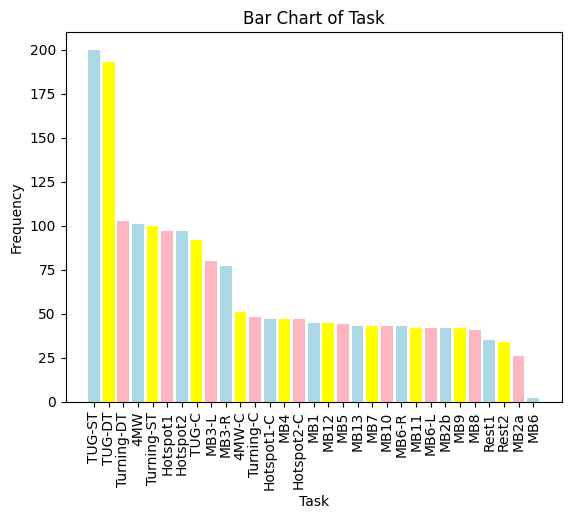

In [29]:
task_counts = merged_data['Task'].value_counts()

colors = ['lightblue', 'yellow', 'lightpink']

plt.bar(task_counts.index, task_counts.values, color=colors)
plt.xlabel('Task')
plt.ylabel('Frequency')
plt.title('Bar Chart of Task')
plt.xticks(rotation=90)
plt.show()

In [30]:
unique_values_task = merged_data['Task'].unique().tolist()
print("Unique values in the 'Task' column:")
print(unique_values_task)

Unique values in the 'Task' column:
['Rest1', 'Rest2', '4MW', '4MW-C', 'MB1', 'MB2a', 'MB2b', 'MB3-R', 'MB3-L', 'MB4', 'MB5', 'MB6-R', 'MB6-L', 'MB7', 'MB8', 'MB9', 'MB10', 'MB11', 'MB12', 'MB13', 'TUG-ST', 'TUG-DT', 'TUG-C', 'Turning-ST', 'Turning-DT', 'Turning-C', 'Hotspot1', 'Hotspot1-C', 'Hotspot2', 'Hotspot2-C', 'MB6']


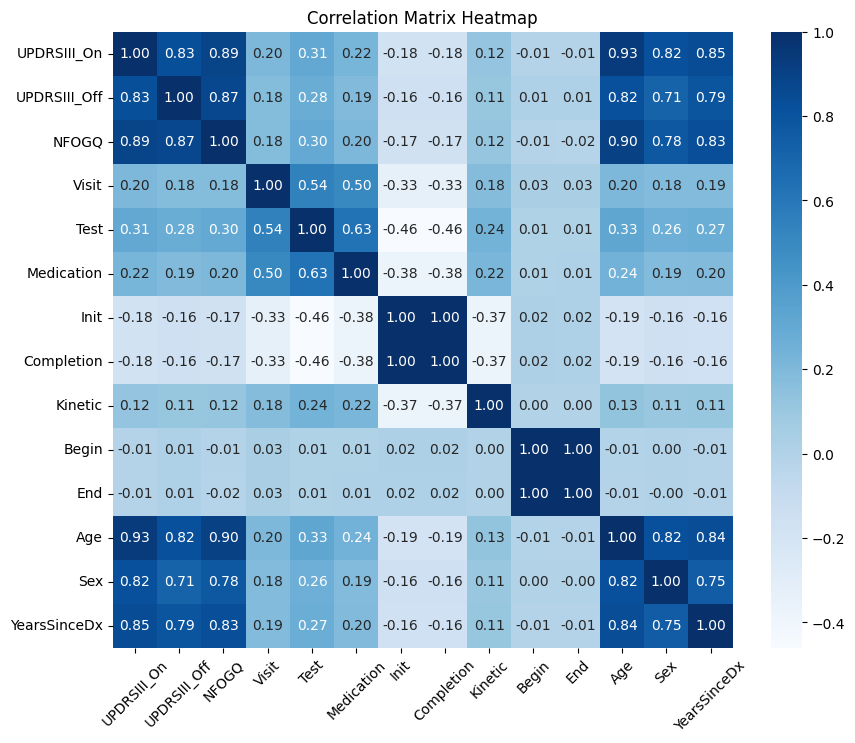

In [31]:
# Calculation of correlation matrix

correlation_matrix = merged_data[['UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ', 'Visit', 'Test', 'Medication', 'Init', 'Completion', 'Kinetic', 'Begin', 'End', 'Age', 'Sex', 'YearsSinceDx']].corr()

# Creating a heatmap of the correlation matrix

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='Blues', annot=True, fmt=".2f", annot_kws={"fontsize": 10})
plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [32]:
X = merged_data[['Medication', 'Kinetic', 'Task', 'Age', 'Sex', 'YearsSinceDx']]
y = merged_data[['UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# Encoding categorical features using OneHotEncoder

categorical_features = ['Task']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

In [34]:
# Standardizing numerical features
numeric_features = ['Medication', 'Kinetic', 'Age', 'Sex', 'YearsSinceDx']
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numeric_features]), columns=numeric_features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numeric_features]), columns=numeric_features)

In [35]:
# Concatenating the transformed features

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_features))
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(categorical_features))
X_train_processed = pd.concat([X_train_encoded_df, X_train_scaled], axis=1)
X_test_processed = pd.concat([X_test_encoded_df, X_test_scaled], axis=1)

In [36]:
# Handling missing values

imputer = SimpleImputer(strategy='mean')
X_train_processed = pd.DataFrame(imputer.fit_transform(X_train_processed), columns=X_train_processed.columns)
X_test_processed = pd.DataFrame(imputer.transform(X_test_processed), columns=X_test_processed.columns)

In [37]:
# Creating and training the model for UPDRSIII_On

logistic_regression_on = LogisticRegression(max_iter=5000)
logistic_regression_on.fit(X_train_processed, y_train['UPDRSIII_On'])

# Creating and training the model for UPDRSIII_Off

logistic_regression_off = LogisticRegression(max_iter=5000)
logistic_regression_off.fit(X_train_processed, y_train['UPDRSIII_Off'])

# Creating and training the model for NFOGQ

logistic_regression_nfogq = LogisticRegression(max_iter=5000)
logistic_regression_nfogq.fit(X_train_processed, y_train['NFOGQ'])

y_train_pred_on = logistic_regression_on.predict(X_train_processed)
y_test_pred_on = logistic_regression_on.predict(X_test_processed)

y_train_pred_off = logistic_regression_off.predict(X_train_processed)
y_test_pred_off = logistic_regression_off.predict(X_test_processed)

y_train_pred_nfogq = logistic_regression_nfogq.predict(X_train_processed)
y_test_pred_nfogq = logistic_regression_nfogq.predict(X_test_processed)

In [38]:
from joblib import dump

# Creating and training the combined model

combined_model = {
    'UPDRSIII_On': logistic_regression_on,
    'UPDRSIII_Off': logistic_regression_off,
    'NFOGQ': logistic_regression_nfogq
}

# Saving the combined model

dump(combined_model, 'combined_model.joblib')

['combined_model.joblib']

In [39]:
metrics_results = []

# Metrics for the model UPDRSIII_On
class_name = 'UPDRSIII_On'
train_accuracy = accuracy_score(y_train[class_name], y_train_pred_on)
test_accuracy = accuracy_score(y_test[class_name], y_test_pred_on)
f1 = f1_score(y_test[class_name], y_test_pred_on, average='weighted')

metrics_results.append({
    'Class': class_name,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'F1 Score': f1
})

# Metrics for the model UPDRSIII_Off
class_name = 'UPDRSIII_Off'
train_accuracy = accuracy_score(y_train[class_name], y_train_pred_off)
test_accuracy = accuracy_score(y_test[class_name], y_test_pred_off)
f1 = f1_score(y_test[class_name], y_test_pred_off, average='weighted')

metrics_results.append({
    'Class': class_name,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'F1 Score': f1
})

# Metrics for the model NFOGQ
class_name = 'NFOGQ'
train_accuracy = accuracy_score(y_train[class_name], y_train_pred_nfogq)
test_accuracy = accuracy_score(y_test[class_name], y_test_pred_nfogq)
f1 = f1_score(y_test[class_name], y_test_pred_nfogq, average='weighted')

metrics_results.append({
    'Class': class_name,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'F1 Score': f1
})

# Output of the results
for metrics in metrics_results:
    print(f"Metrics for class '{metrics['Class']}':")
    print(f"Train Accuracy: {metrics['Train Accuracy']}")
    print(f"Test Accuracy: {metrics['Test Accuracy']}")
    print(f"F1 Score: {metrics['F1 Score']}")
    print()

Metrics for class 'UPDRSIII_On':
Train Accuracy: 0.9460138104205901
Test Accuracy: 0.924812030075188
F1 Score: 0.9235605929573596

Metrics for class 'UPDRSIII_Off':
Train Accuracy: 0.9409918392969241
Test Accuracy: 0.9323308270676691
F1 Score: 0.9128055741447861

Metrics for class 'NFOGQ':
Train Accuracy: 0.9522912743251726
Test Accuracy: 0.9323308270676691
F1 Score: 0.923362623426035



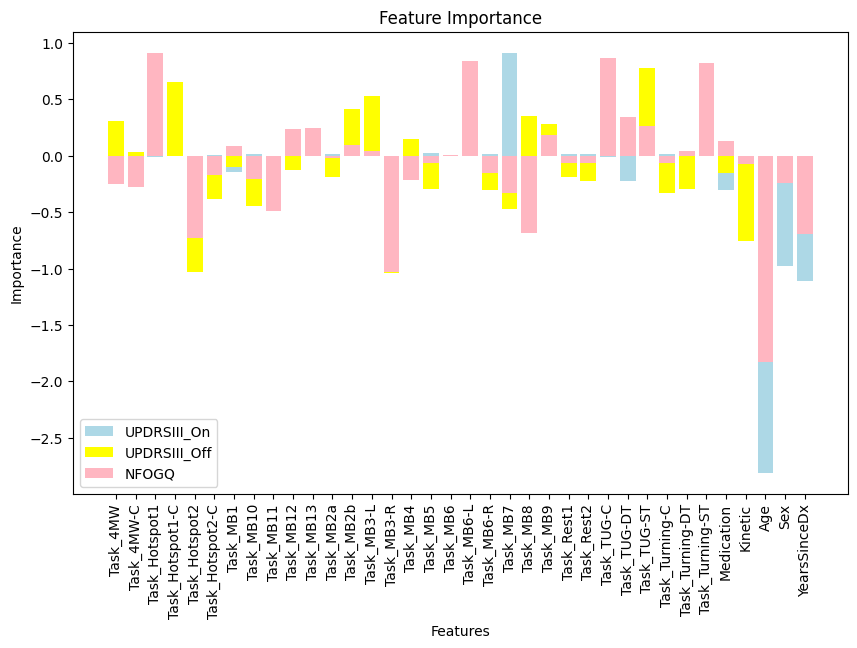

In [40]:
# Creating a list of feature labels for the x-axis

x_labels = X_train_processed.columns

# Creating the plot

plt.figure(figsize=(10, 6))
plt.bar(x_labels, logistic_regression_on.coef_[0], color='lightblue', label='UPDRSIII_On')
plt.bar(x_labels, logistic_regression_off.coef_[0], color='yellow', label='UPDRSIII_Off')
plt.bar(x_labels, logistic_regression_nfogq.coef_[0], color='lightpink', label='NFOGQ')

# Plot settings

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.legend()

# Displaying the plot

plt.show()